<a href="https://colab.research.google.com/github/Uday-1402/ML_Learn/blob/main/data_gathering_lesson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### Just setting up google colab to download datasets from kaggle

In [ ]:
import os
from google.colab import userdata

os.makedirs('/root/.kaggle', exist_ok=True)

# Replace with your actual username and API key
kaggle_config = {
    "username": "udayt14",
    "key": userdata.get('kaggle_key')
}

import json
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_config, f)

os.chmod('/root/.kaggle/kaggle.json', 0o600)

In [ ]:
!pip install kaggle

!kaggle datasets download -d <dataset-owner>/<dataset-name>
!unzip <dataset-name>.zip

/bin/bash: -c: line 1: syntax error near unexpected token `newline'
/bin/bash: -c: line 1: `kaggle datasets download -d <dataset-owner>/<dataset-name>'
/bin/bash: line 1: dataset-name: No such file or directory


In [ ]:
# The below command downloads and unzips the dataset.

In [ ]:
!kaggle datasets download -d kaggle/recipe-ingredients-dataset
!unzip recipe-ingredients-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/kaggle/recipe-ingredients-dataset
License(s): unknown
  0% 0.00/2.23M [00:00<?, ?B/s]
100% 2.23M/2.23M [00:00<00:00, 782MB/s]
Archive:  recipe-ingredients-dataset.zip
  inflating: test.json               
  inflating: train.json              


# Working with JSON

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_json('train.json')

In [ ]:
df

,id,cuisine,ingredients
0,10259,greek,"[romaine lettuce, black olives, grape tomatoes..."
1,25693,southern_us,"[plain flour, ground pepper, salt, tomatoes, g..."
2,20130,filipino,"[eggs, pepper, salt, mayonaise, cooking oil, g..."
3,22213,indian,"[water, vegetable oil, wheat, salt]"
4,13162,indian,"[black pepper, shallots, cornflour, cayenne pe..."
...,...,...,...
39769,29109,irish,"[light brown sugar, granulated sugar, butter, ..."
39770,11462,italian,"[KRAFT Zesty Italian Dressing, purple onion, b..."
39771,2238,irish,"[eggs, citrus fruit, raisins, sourdough starte..."
39772,41882,chinese,"[boneless chicken skinless thigh, minced garli..."


In [ ]:
!kaggle datasets download -d busielmorley/worldcities-pop-lang-rank-sql-create-tbls
!unzip worldcities-pop-lang-rank-sql-create-tbls.zip

Dataset URL: https://www.kaggle.com/datasets/busielmorley/worldcities-pop-lang-rank-sql-create-tbls
License(s): world-bank
  0% 0.00/89.9k [00:00<?, ?B/s]
100% 89.9k/89.9k [00:00<00:00, 258MB/s]
Archive:  worldcities-pop-lang-rank-sql-create-tbls.zip
  inflating: world.sql               


# Working with SQL

In [ ]:
!pip install mysql.connector

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 64.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for mysql.connector: filename=mysql_connector-2.2.9-cp312-cp312-linux_x86_64.whl size=247950 sha256=5c7c664d09f9967e84b0c2fa9ab7dee5bd26cc32f824c51a1e657338927c99d2
  Stored in directory: /root/.cache/pip/wheels/03/17/fa/d7604c72dd3dd6d3eb3d249abf36cc532c9a9b4354b8f1bc4f
Successfully built mysql.connector


In [ ]:
import mysql.connector

In [ ]:
# In the lecture he is using local setup of database using xampp and local jupyter notebook for this part.
# I also have that db set up locally but I am using google colab
# Google colab runs on cloud so it cannot directly access localhost
# So I used ngrok to expose my local mysql server. Hence the host name.
conn = mysql.connector.connect(host='0.tcp.in.ngrok.io',user='root',password='',database='world',port='17903')

In [ ]:
df = pd.read_sql_query("select * from city where CountryCode like 'IND'",conn)

/tmp/ipython-input-618/3831303207.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query("select * from city where CountryCode like 'IND'",conn)


In [ ]:
df

,ID,Name,CountryCode,District,Population
0,1024,Mumbai (Bombay),IND,Maharashtra,10500000
1,1025,Delhi,IND,Delhi,7206704
2,1026,Calcutta [Kolkata],IND,West Bengali,4399819
3,1027,Chennai (Madras),IND,Tamil Nadu,3841396
4,1028,Hyderabad,IND,Andhra Pradesh,2964638
...,...,...,...,...,...
336,1360,Ambala Sadar,IND,Haryana,90712
337,1361,Baidyabati,IND,West Bengali,90601
338,1362,Morvi,IND,Gujarat,90357
339,1363,Raigarh,IND,Chhatisgarh,89166


In [ ]:
!git config --global user.email "udayt1402@gmail.com"
!git config --global user.name "Uday-1402"

In [ ]:
from google.colab import userdata

token = userdata.get('github_pat')

# Use it in your git remote URL
!git remote set-url origin https://{token}@github.com/Uday-1402/ML_Learn

fatal: not a git repository (or any of the parent directories): .git


# Working with APIs

In [ ]:
import pandas as pd

In [ ]:
import requests

In [ ]:
response = requests.get("https://api.themoviedb.org/3/discover/movie?api_key=7ab284ec859efcd7a29ef82c737662b4")

In [ ]:
df = pd.DataFrame()

In [ ]:
dfs = []
for i in range(1,429):
  response = requests.get(f"https://api.themoviedb.org/3/discover/movie?api_key=7ab284ec859efcd7a29ef82c737662b4&page={i}")
  tmp_df = pd.DataFrame(response.json()['results'])[['id','title','release_date','popularity','overview','vote_average','vote_count']]
  dfs.append(tmp_df)
df = pd.concat(dfs,ignore_index=True)

In [ ]:
df

,id,title,release_date,popularity,overview,vote_average,vote_count
0,1290821,Shelter,2026-01-28,543.5405,A man living in self-imposed exile on a remote...,6.792,180
1,799882,The Bluff,2026-02-17,390.8723,When her tranquil life on a remote island is s...,5.873,126
2,1199193,Pose,2026-02-25,281.4318,"Isolated in a grand country manor, a reclusive...",8.200,10
3,1159559,Scream 7,2026-02-25,239.3962,When a new Ghostface killer emerges in the qui...,5.997,171
4,680493,Return to Silent Hill,2026-01-21,228.6204,When James receives a mysterious letter from h...,5.045,221
...,...,...,...,...,...,...,...
8555,1504899,Recluse,,8.5214,Joan is a solitary audio engineer who returns ...,0.000,0
8556,486198,"Wo bleibst du, Baby?",2005-01-01,8.3703,,0.000,0
8557,271433,Wir sind die Neuen,2014-07-17,7.5784,Three old friends from college move back in to...,6.536,70
8558,890504,The Journey Away,1945-12-26,8.3142,Bernt comes to a small town to rob the bank. B...,1.000,2


In [ ]:
df.shape()

TypeError: 'tuple' object is not callable

In [ ]:
df.shape

(8560, 7)

In [ ]:
df.to_csv('movies.csv')

Datasets used :-
1. recipe from kaggle (json)
2. worldcities-pop-lang-rank-sql-create-tbls from kaggle (sql)

# Web Scraping

In [1]:
import pandas as pd

In [2]:
import requests

In [3]:
from bs4 import BeautifulSoup #This the web scraping library

In [4]:
# url of website used for webscraping : 'https://www.ambitionbox.com/list-of-companies?page=1' (didn't work), url2 : 'https://www.hirist.tech/c/ai-ml-jobs?ref=homepagecat&pref=google'

In [5]:
requests.get('https://www.hirist.tech/c/ai-ml-jobs?ref=homepagecat&pref=google')

<Response [403]>

In [6]:
requests.get('https://www.hirist.tech/c/ai-ml-jobs?ref=homepagecat&pref=google').text

''

In [7]:
# website thinks us as a bot. Done with something called robots.txt. Files is this cannot be accessed by hitting the url with direct http requests. Instead make it look like the request comes through a browser.

In [16]:
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,*/*;q=0.8",
    "Accept-Language": "en-US,en;q=0.9",
    "Accept-Encoding": "gzip, deflate, br",
    "Connection": "keep-alive",
    "Referer": "https://www.google.com/",
    "Sec-Fetch-Dest": "document",
    "Sec-Fetch-Mode": "navigate",
    "Sec-Fetch-Site": "none",
    "Sec-Fetch-User": "?1",
}
url = "https://www.hirist.tech/c/ai-ml-jobs?ref=topnavigation&pref=google"

In [17]:
webpage = requests.get(url,headers=headers).text

In [18]:
soup = BeautifulSoup(webpage,'lxml')

<!DOCTYPE html>
<html lang="en" style="background:#F2F5FA">
 <head>
  <meta charset="utf-8"/>
  <meta content="width=device-width, initial-scale=1, maximum-scale=1" name="viewport"/>
  <title>
   AI/ML Jobs,  Job Vacancies for AI/ML in March 2026 | hirist.tech
  </title>
  <meta content="index,follow" name="robots"/>
  <meta content="Apply to  AI/ML Jobs on hirist.tech. Find high paying premium AI/ML Jobs openings with salary details in major cities in India." name="description"/>
  <meta content="AI/ML Jobs,  Job Vacancies for AI/ML in March 2026 | hirist.tech" property="og:title"/>
  <meta content="Apply to  AI/ML Jobs on hirist.tech. Find high paying premium AI/ML Jobs openings with salary details in major cities in India." property="og:description"/>
  <meta content="https://www.hirist.tech/c/ai-ml-jobs" property="og:url"/>
  <meta content="website" property="og:type"/>
  <meta content="https://staticlogo.hirist.com/webp/hirist-tech-logo.webp" property="og:image"/>
  <meta content=
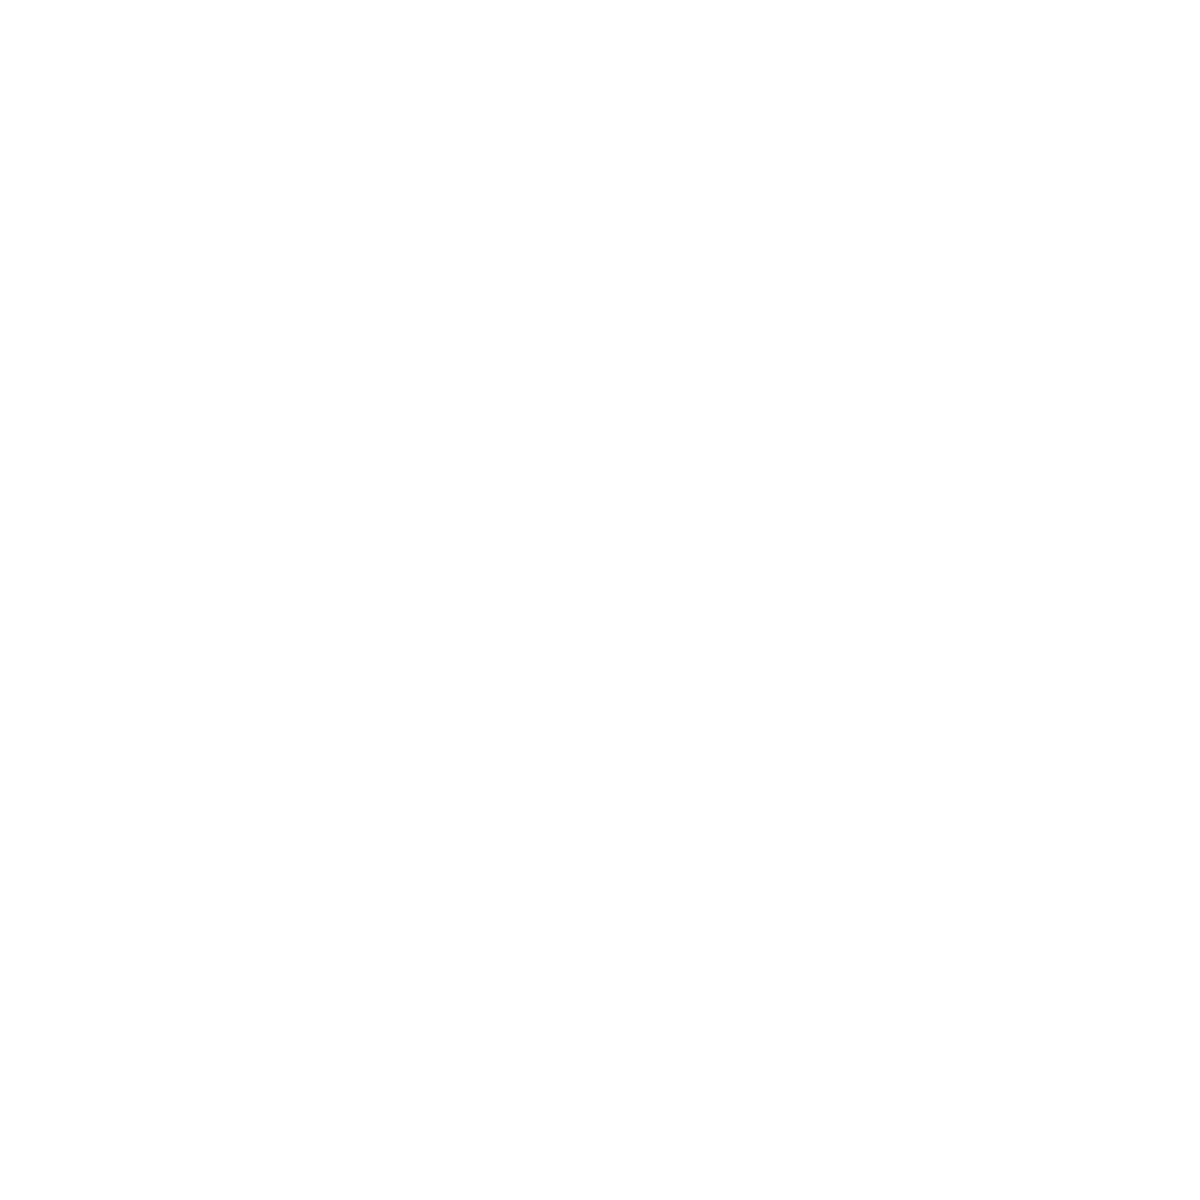
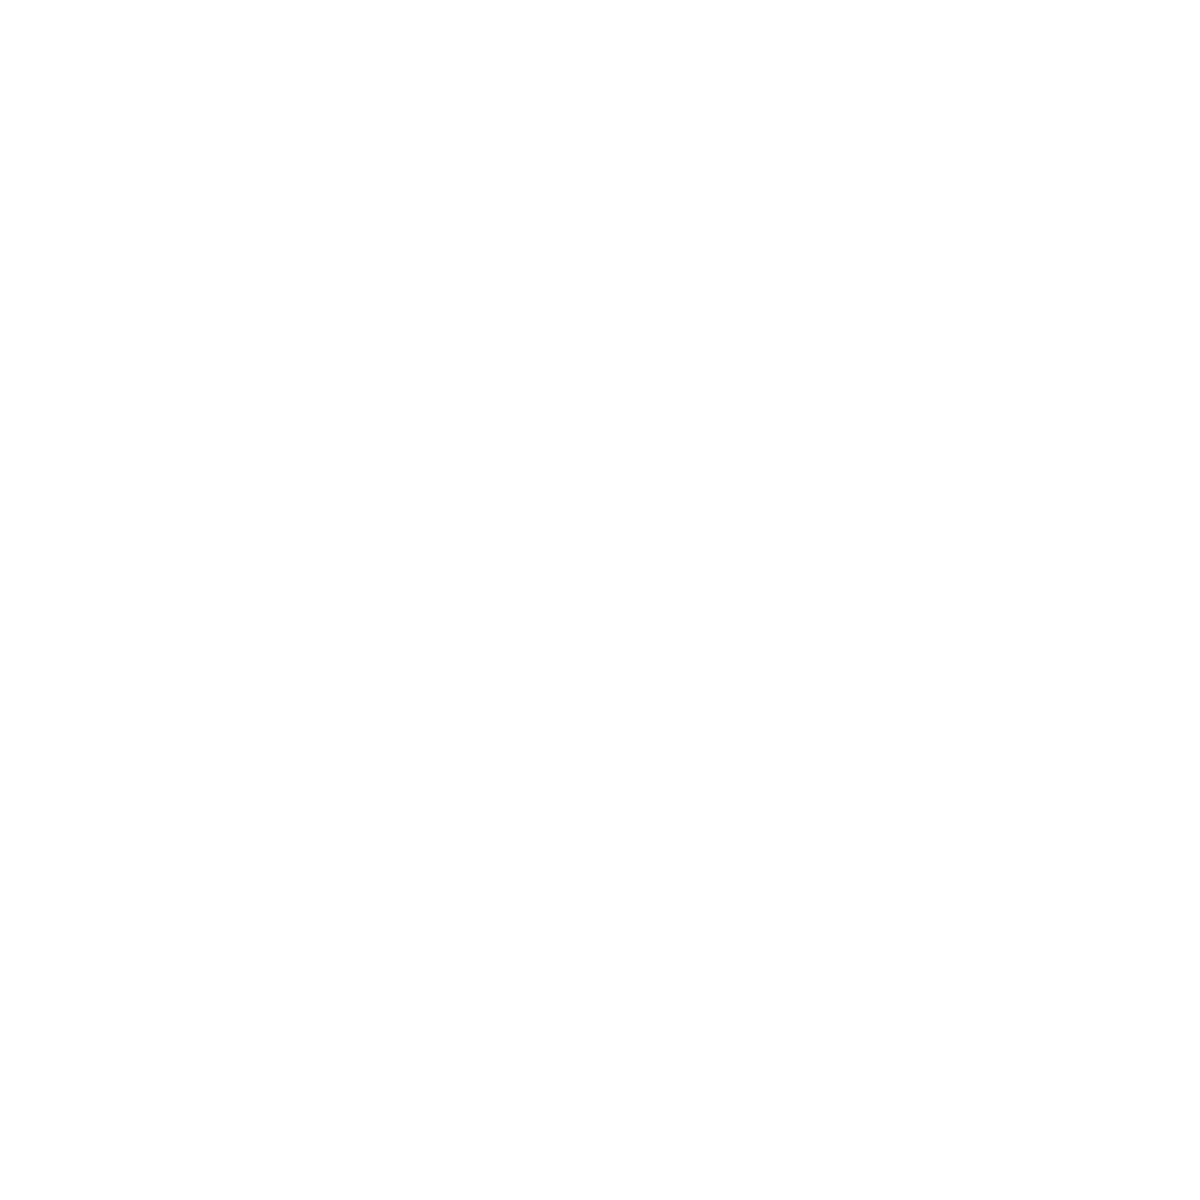

In [19]:
print(soup.prettify())

# I was trying to do web scraping but in the process I found out how I can find out hidden APIs in network tab. It might be small for many people but this trick of checking out the network tab to get the API responsible for generating the responses looks cool to me.

In [38]:
# url : https://gladiator.hirist.tech/job/category/?page=0&industry=&categoryId=14&size=20&ref=topnavigation&referenceText=topnavigation&pref=google&refPool=%7B%22ref%22:%22topnavigation%22,%22pref%22:%22google%22%7D
# response = requests.get(f"https://api.themoviedb.org/3/discover/movie?api_key=7ab284ec859efcd7a29ef82c737662b4&page={i}")
# tmp_df = pd.DataFrame(response.json()['results'])[['id','title','release_date','popularity','overview','vote_average','vote_count']]
# dfs.append(tmp_df)
jobPosts = []
for page in range (0,21):
  res = requests.get(f'https://gladiator.hirist.tech/job/category/?page={page}&industry=&categoryId=14&size=20&ref=topnavigation&referenceText=topnavigation&pref=google',headers=headers)
  tmp_df = pd.DataFrame(res.json()['data'])[['id','title','min','max','jobdesignation','jobDetailUrl','applyCount','tags']]
  jobPosts.append(tmp_df)
df = pd.concat(jobPosts,ignore_index=True)
df

,id,title,min,max,jobdesignation,jobDetailUrl,applyCount,tags
0,1615803,American Express - Senior AI Engineer I - Agen...,6,10,Senior AI Engineer I,https://www.hirist.tech/j/american-express-sen...,147,"[{'id': 898, 'name': 'Artificial Intelligence'..."
1,1615808,American Express - Senior AI Engineer II - Age...,8,15,Senior AI Engineer II,https://www.hirist.tech/j/american-express-sen...,136,"[{'id': 240195, 'name': 'Agentic AI', 'isManda..."
2,1615793,American Express - Staff Data Engineer - Agent...,10,15,Staff Data Engineer,https://www.hirist.tech/j/american-express-sta...,119,"[{'id': 170423, 'name': 'Data Engineering', 'i..."
3,1615819,American Express - Senior Staff Data Engineer ...,15,20,Senior Staff Data Engineer,https://www.hirist.tech/j/american-express-sen...,135,"[{'id': 240195, 'name': 'Agentic AI', 'isManda..."
4,1615779,American Express - AI Engineer III - Agentic AI,4,8,AI Engineer III,https://www.hirist.tech/j/american-express-ai-...,242,"[{'id': 898, 'name': 'Artificial Intelligence'..."
...,...,...,...,...,...,...,...,...
415,1613207,Generative AI Expert - LLM/RAG,7,10,Generative AI Expert,https://www.hirist.tech/j/generative-ai-expert...,10,"[{'id': 135480, 'name': 'Generative AI', 'isMa..."
416,1613528,Eternal Robotics - Artificial Intelligence Eng...,7,10,Artificial Intelligence Engineer,https://www.hirist.tech/j/eternal-robotics-art...,8,"[{'id': 811, 'name': 'Computer Vision', 'isMan..."
417,1613505,Voice & AI Engineer - Telephony Platform,2,6,Voice & AI Engineer,https://www.hirist.tech/j/voice-ai-engineer-te...,36,"[{'id': 898, 'name': 'Artificial Intelligence'..."
418,1613329,Software Co - AI Engineering Lead,7,10,AI Engineering Lead,https://www.hirist.tech/j/software-co-ai-engin...,5,"[{'id': 898, 'name': 'Artificial Intelligence'..."
